<a href="https://www.kaggle.com/code/guludutta321/cyberbully-final?scriptVersionId=331888262" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Advanced Cyberbullying Detection Using Machine Learning

Complete project notebook with:
- Multi-dataset training
- Multilingual toxic comments
- TF-IDF vectorization
- Multiple ML models
- GPU XGBoost
- Automatic best model selection
- Advanced evaluation graphs
- Real-time prediction


In [1]:
!pip install nltk xgboost scikit-learn pandas numpy matplotlib seaborn wordcloud imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

from wordcloud import WordCloud

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Datasets

In [3]:
path1 = '/kaggle/input/datasets/andrewmvd/cyberbullying-classification/cyberbullying_tweets.csv'

path2 = '/kaggle/input/datasets/mrmorj/hate-speech-and-offensive-language-dataset/labeled_data.csv'

path3 = '/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv'

path4 = '/kaggle/input/competitions/jigsaw-multilingual-toxic-comment-classification/jigsaw-toxic-comment-train.csv'

df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)
df3 = pd.read_csv(path3)
df4 = pd.read_csv(path4)

print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)


(47692, 2)
(24783, 7)
(159571, 8)
(223549, 8)


In [4]:
# Advanced Text Preprocessing

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def advanced_clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(words)


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


## Dataset Preprocessing

In [5]:
# DATASET 1
df1 = df1.rename(columns={
    'tweet_text':'text',
    'cyberbullying_type':'label'
})

df1 = df1[['text', 'label']]

df1['label'] = df1['label'].apply(
    lambda x: 0 if x == 'not_cyberbullying' else 1
)

# DATASET 2
df2 = df2.rename(columns={
    'tweet':'text',
    'class':'label'
})

df2 = df2[['text', 'label']]

df2['label'] = df2['label'].apply(
    lambda x: 0 if x == 2 else 1
)

# DATASET 3
df3['label'] = (
    df3[['toxic', 'severe_toxic',
         'obscene', 'threat',
         'insult', 'identity_hate']]
    .sum(axis=1)
)

df3['label'] = df3['label'].apply(
    lambda x: 1 if x > 0 else 0
)

df3 = df3.rename(columns={
    'comment_text':'text'
})

df3 = df3[['text', 'label']]

# DATASET 4
df4 = df4.rename(columns={
    'comment_text':'text',
    'toxic':'label'
})

df4 = df4[['text', 'label']]

df4.dropna(inplace=True)

# Sample multilingual dataset for RAM optimization
df4 = df4.sample(
    n=100000,
    random_state=42
)

print(df4.shape)


(100000, 2)


## Merge Datasets

In [6]:
combined_df = pd.concat(
    [df1, df2, df3, df4],
    ignore_index=True
)

combined_df.drop_duplicates(inplace=True)
combined_df.dropna(inplace=True)

combined_df['label'] = combined_df['label'].astype(int)

combined_df = combined_df[
    combined_df['label'].isin([0,1])
]

print(combined_df.shape)

print(combined_df['label'].value_counts())


(261284, 2)
label
0    182128
1     79156
Name: count, dtype: int64


## Label Distribution

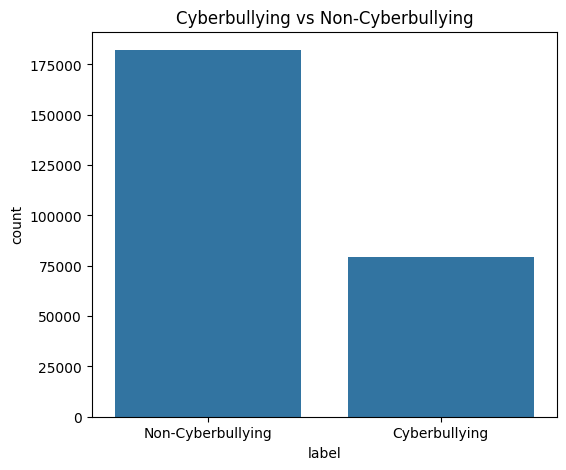

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=combined_df['label']
)

plt.title('Cyberbullying vs Non-Cyberbullying')

plt.xticks(
    [0,1],
    ['Non-Cyberbullying', 'Cyberbullying']
)

plt.show()


## Text Cleaning

In [8]:
combined_df['clean_text'] = combined_df['text'].apply(advanced_clean_text)

print("Sample Cleaned Text:")
print(combined_df[['text', 'clean_text']].head())


Sample Cleaned Text:
                                                text  \
0  In other words #katandandre, your food was cra...   
1  Why is #aussietv so white? #MKR #theblock #ImA...   
2  @XochitlSuckkks a classy whore? Or more red ve...   
3  @Jason_Gio meh. :P  thanks for the heads up, b...   
4  @RudhoeEnglish This is an ISIS account pretend...   

                                          clean_text  
0                             word food crapilicious  
1                                              white  
2                    classy whore red velvet cupcake  
3  meh thanks head concerned another angry dude t...  
4  isi account pretending kurdish account like is...  


## WordCloud

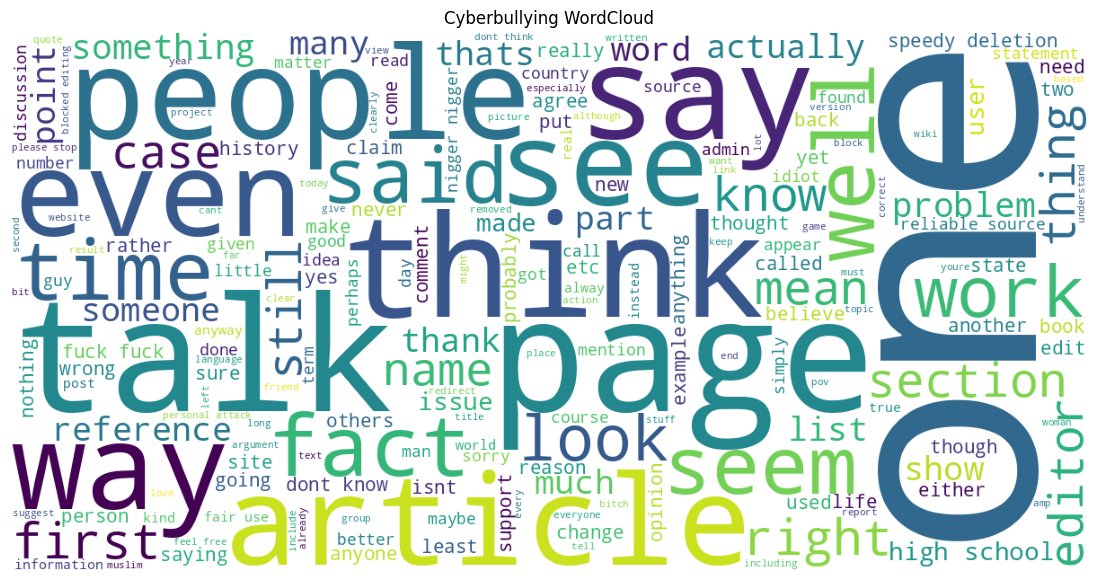

In [9]:
text_data = ' '.join(combined_df['clean_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text_data)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('Cyberbullying WordCloud')

plt.show()


## TF-IDF Vectorization

In [10]:
vectorizer = TfidfVectorizer(
    max_features=80000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    strip_accents='unicode',
    dtype=np.float32
)

X = vectorizer.fit_transform(
    combined_df['clean_text']
)

y = combined_df['label']

print(X.shape)


(261284, 80000)


## Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Handle Class Imbalance

In [12]:
counter = Counter(y)

scale_pos_weight = counter[0] / counter[1]

print(counter)

print(scale_pos_weight)


Counter({0: 182128, 1: 79156})
2.3008742230532113


## Train Models

In [13]:
# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(

    n_estimators=50,

    max_depth=20,

    n_jobs=-1,

    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# SVM
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

# GPU XGBoost
xgb_model = XGBClassifier(

    tree_method='hist',
    device='cuda',

    n_estimators=1000,

    learning_rate=0.03,

    max_depth=12,

    min_child_weight=2,

    subsample=0.85,

    colsample_bytree=0.85,

    gamma=0.15,

    scale_pos_weight=scale_pos_weight,

    eval_metric='logloss',

    random_state=42,

    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

y_probs = xgb_model.predict_proba(X_test)[:,1]

xgb_pred = (y_probs > 0.35).astype(int)


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:43:39] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


## Auto Select Best Model

In [14]:
models = {
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
    'Random Forest': rf_model,
    'SVM': svm_model,
    'XGBoost': xgb_model
}

predictions = {
    'Logistic Regression': lr_pred,
    'Naive Bayes': nb_pred,
    'Random Forest': rf_pred,
    'SVM': svm_pred,
    'XGBoost': xgb_pred
}

model_scores = {}

for name in models:

    score = f1_score(
        y_test,
        predictions[name]
    )

    model_scores[name] = score

best_model_name = max(
    model_scores,
    key=model_scores.get
)

best_model = models[best_model_name]

print('Best Model:', best_model_name)

print('Best F1 Score:', model_scores[best_model_name])


Best Model: Logistic Regression
Best F1 Score: 0.8630173924767426


## Classification Reports

In [15]:
print('LOGISTIC REGRESSION')
print(classification_report(y_test, lr_pred))

print('NAIVE BAYES')
print(classification_report(y_test, nb_pred))

print('RANDOM FOREST')
print(classification_report(y_test, rf_pred))

print('SVM')
print(classification_report(y_test, svm_pred))

print('XGBOOST')
print(classification_report(y_test, xgb_pred))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     36426
           1       0.93      0.81      0.86     15831

    accuracy                           0.92     52257
   macro avg       0.92      0.89      0.90     52257
weighted avg       0.92      0.92      0.92     52257

NAIVE BAYES
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     36426
           1       0.86      0.82      0.84     15831

    accuracy                           0.91     52257
   macro avg       0.89      0.88      0.89     52257
weighted avg       0.91      0.91      0.91     52257

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.73      1.00      0.84     36426
           1       1.00      0.15      0.26     15831

    accuracy                           0.74     52257
   macro avg       0.86      0.57      0.55     52257
weighted avg       0.81     

## Metrics Comparison

In [16]:
metrics_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Random Forest',
        'SVM',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, xgb_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, xgb_pred)
    ],

    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, xgb_pred)
    ]
})

metrics_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.922231,0.925201,0.808667,0.863017
1,Naive Bayes,0.906137,0.862028,0.821679,0.841370
2,Random Forest,0.742235,0.997472,0.149517,0.260053
3,SVM,0.917523,0.897852,0.821174,0.857803
4,XGBoost,0.631973,0.273478,0.129682,0.175936


## Accuracy Comparison Graph

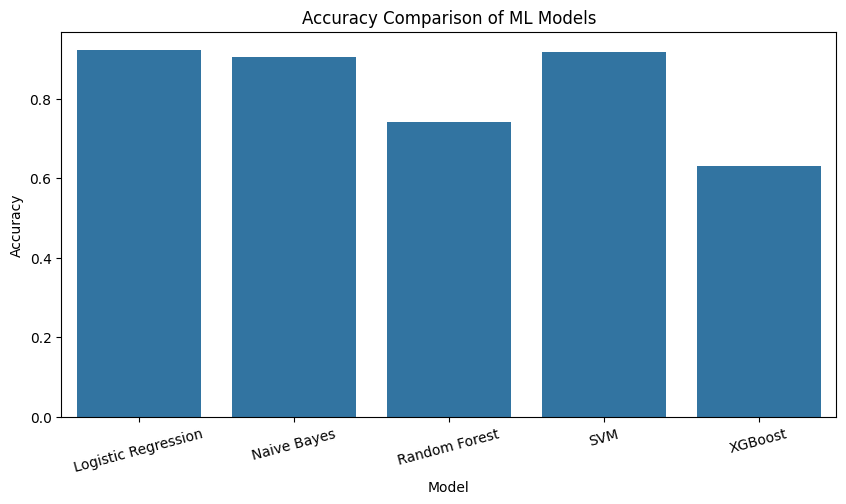

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=metrics_df
)

plt.title('Accuracy Comparison of ML Models')

plt.xticks(rotation=15)

plt.show()


## Precision Recall F1 Comparison

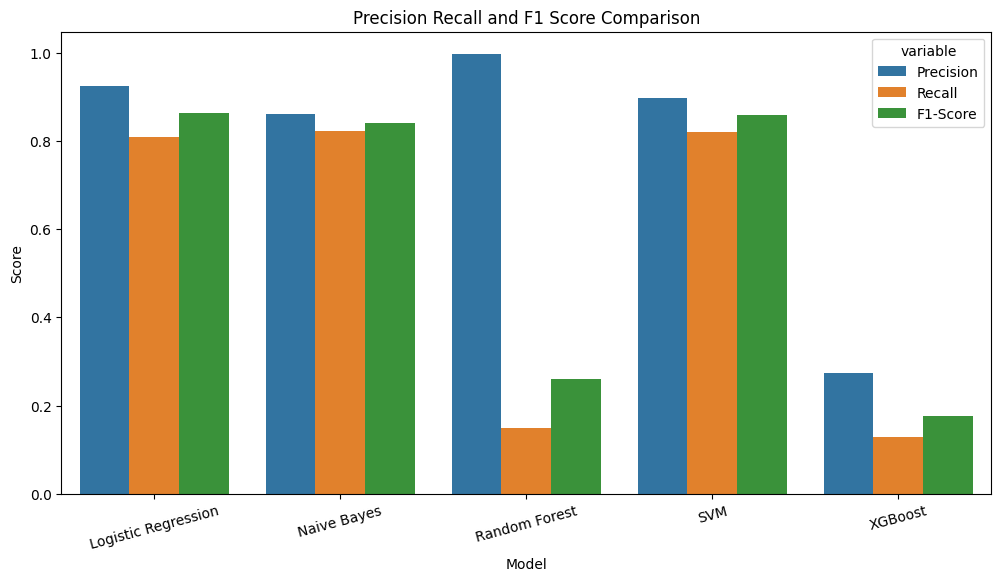

In [18]:
metrics_melted = metrics_df.melt(
    id_vars='Model',
    value_vars=['Precision', 'Recall', 'F1-Score']
)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='value',
    hue='variable',
    data=metrics_melted
)

plt.title('Precision Recall and F1 Score Comparison')

plt.ylabel('Score')

plt.xticks(rotation=15)

plt.show()


## Confusion Matrix

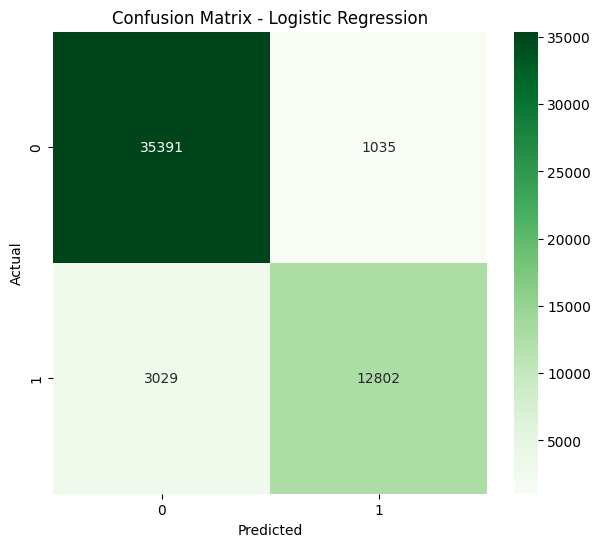

In [19]:
# Confusion Matrix for Best Model

best_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(f'Confusion Matrix - {best_model_name}')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()


## ROC Curve

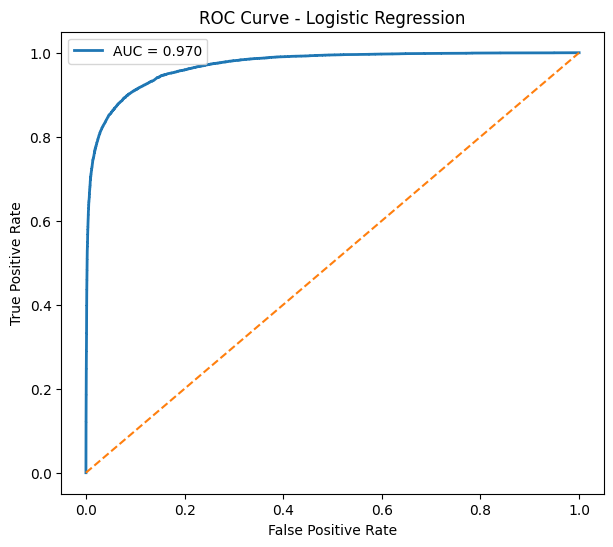

In [20]:
# ROC Curve for Best Model

if hasattr(best_model, 'predict_proba'):
    
    best_probs = best_model.predict_proba(X_test)[:,1]

else:
    
    best_scores = best_model.decision_function(X_test)
    
    best_probs = (
        best_scores - best_scores.min()
    ) / (
        best_scores.max() - best_scores.min()
    )

fpr, tpr, thresholds = roc_curve(
    y_test,
    best_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title(f'ROC Curve - {best_model_name}')

plt.legend()

plt.show()


## Feature Importance

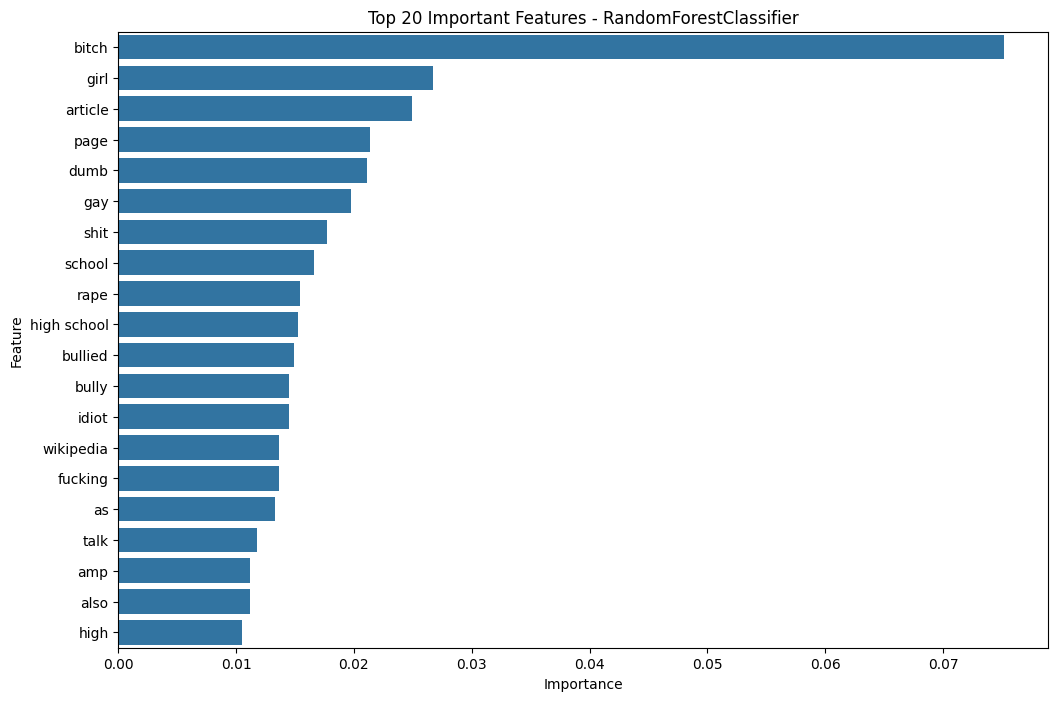

In [21]:
# Feature Importance for Best Tree-Based Model

tree_model = xgb_model if best_model_name == 'XGBoost' else rf_model

importance = tree_model.feature_importances_

feature_names = vectorizer.get_feature_names_out()

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title(f'Top 20 Important Features - {type(tree_model).__name__}')

plt.show()


## Additional Relevant Graphs

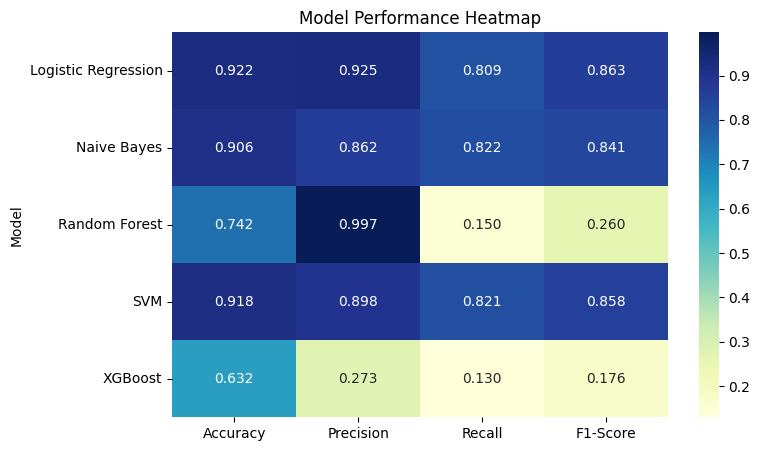

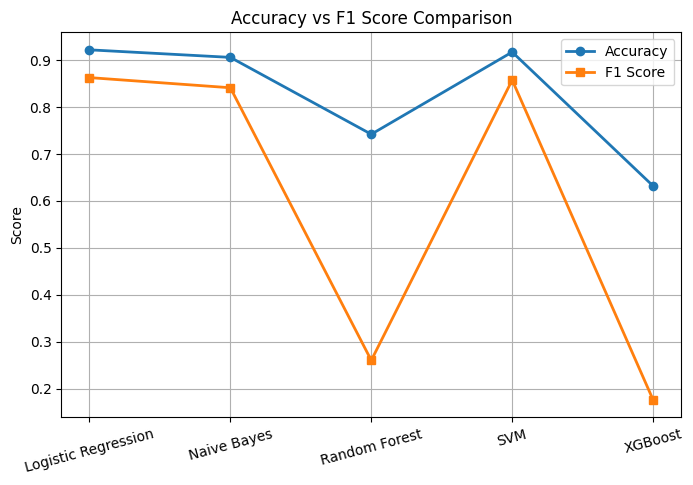

In [22]:
# Additional Relevant Graphs

# Model Comparison Heatmap
plt.figure(figsize=(8,5))

heatmap_df = metrics_df.set_index('Model')

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap='YlGnBu',
    fmt='.3f'
)

plt.title('Model Performance Heatmap')

plt.show()

# Accuracy vs F1 Score
plt.figure(figsize=(8,5))

plt.plot(
    metrics_df['Model'],
    metrics_df['Accuracy'],
    marker='o',
    linewidth=2,
    label='Accuracy'
)

plt.plot(
    metrics_df['Model'],
    metrics_df['F1-Score'],
    marker='s',
    linewidth=2,
    label='F1 Score'
)

plt.xticks(rotation=15)

plt.ylabel('Score')

plt.title('Accuracy vs F1 Score Comparison')

plt.legend()

plt.grid(True)

plt.show()


## Additional NLP Visualizations

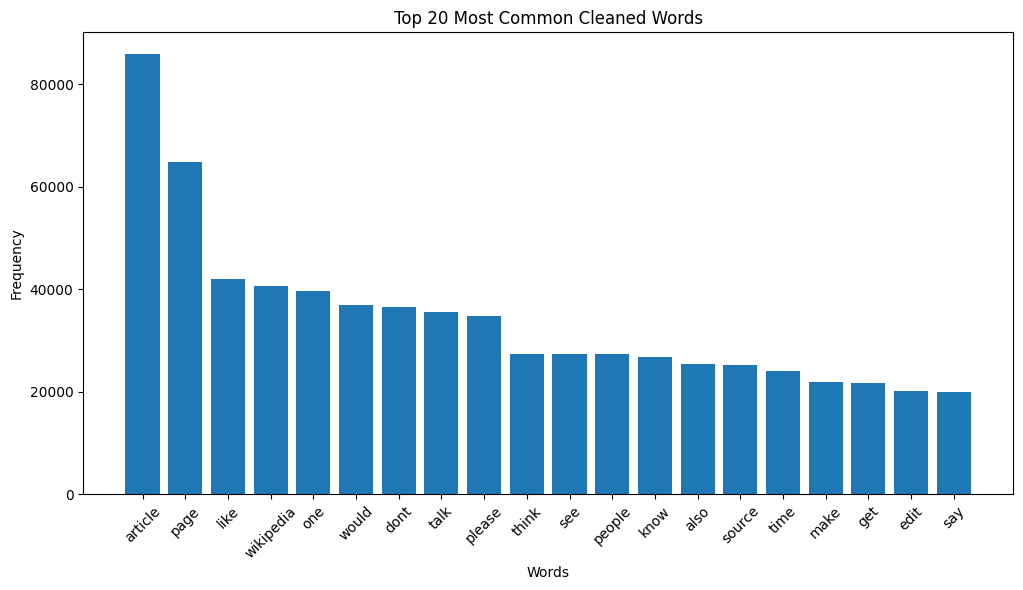

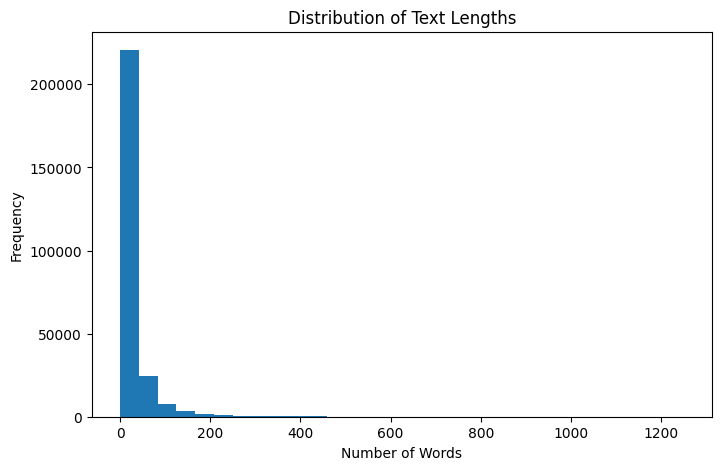

In [23]:
# Additional NLP Visualizations

from collections import Counter

# Most Common Words
all_words = ' '.join(combined_df['clean_text']).split()

common_words = Counter(all_words).most_common(20)

words = [word[0] for word in common_words]

counts = [word[1] for word in common_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title('Top 20 Most Common Cleaned Words')

plt.xlabel('Words')

plt.ylabel('Frequency')

plt.show()

# Text Length Distribution
text_lengths = combined_df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))

plt.hist(text_lengths, bins=30)

plt.title('Distribution of Text Lengths')

plt.xlabel('Number of Words')

plt.ylabel('Frequency')

plt.show()


## Real Time Prediction

In [24]:
def predict_cyberbullying(text):

    cleaned = advanced_clean_text(text)

    vectorized = vectorizer.transform([cleaned])

    if hasattr(best_model, 'predict_proba'):

        probability = best_model.predict_proba(vectorized)[0][1]

        prediction = 1 if probability > 0.35 else 0

        score = probability

    elif hasattr(best_model, 'decision_function'):

        score = best_model.decision_function(vectorized)[0]

        prediction = 1 if score > -0.5 else 0

    else:

        prediction = best_model.predict(vectorized)[0]

        score = 0

    if prediction == 1:

        return (
            f'Cyberbullying Detected '
            f'using {best_model_name} '
            f'(Score: {score:.2f})'
        )

    else:

        return (
            f'Non-Cyberbullying '
            f'using {best_model_name} '
            f'(Score: {score:.2f})'
        )

print(predict_cyberbullying("You are useless and nobody likes you"))

print(predict_cyberbullying("Go kill yourself"))

print(predict_cyberbullying("Have a nice day"))


Cyberbullying Detected using Logistic Regression (Score: 0.43)
Cyberbullying Detected using Logistic Regression (Score: 0.86)
Non-Cyberbullying using Logistic Regression (Score: 0.12)
